In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

from xgboost import XGBClassifier

import matplotlib.pyplot as plt

import joblib

In [2]:
class Config:
    RANDOM_STATE = 42
    TEST_SIZE = 0.20

    MODEL_NAME = "best_xgboost_model.pkl"

    TARGET_COLUMN = "label"
    IMAGE_COLUMN = "image"

In [3]:
# Load Dataset
df = pd.read_csv("multimodal_features.csv")

print(df.shape)

df.head()

(1500, 793)


,image,label,resnet_0,resnet_1,resnet_2,resnet_3,resnet_4,resnet_5,resnet_6,resnet_7,...,l_mean,a_mean,b_mean,l_std,a_std,b_std,edge_density,laplacian_var,bright_ratio,dark_ratio
0,02137a86-0743-40e0-845b-6d22d1d5cc85.png,0,1.503252,0.733779,1.513309,0.041626,1.466865,1.763368,0.650255,1.772707,...,78.253960,125.864445,135.298550,45.371385,4.454920,5.600768,0.012070,219.483629,0.000000,0.347080
1,025d39a8-7859-4558-9bf9-bbdd475c6100.png,0,1.567873,1.037666,0.364339,0.587060,1.974926,1.137942,0.527725,0.449724,...,76.909702,123.298275,133.852314,39.861752,4.374290,3.988359,0.018215,229.052303,0.000000,0.272717
2,02a2a878-c5a4-490a-8061-6b2f4ac3b6d0.png,0,0.411265,1.356105,1.317105,0.094091,0.854148,0.370707,0.005329,0.210806,...,102.359478,128.527328,138.830452,49.641611,4.502393,5.323365,0.035538,281.944820,0.055027,0.188370
3,047f7996-9f0d-4a04-ae7f-24e246c407c7.png,0,1.107608,3.403687,1.248990,0.789486,0.320989,2.138436,2.261848,1.083504,...,47.191967,122.214401,129.895306,30.074583,4.816540,6.653980,0.020493,237.096365,0.000000,0.674461
4,052a9d62-a31f-4e4f-9a76-edac2d2ae95d.png,0,1.085853,1.090163,1.399769,1.643254,0.359540,0.761260,0.610737,1.538106,...,58.798435,116.122681,136.325592,34.338513,6.066670,4.152095,0.010010,225.819341,0.000000,0.628185


In [4]:
print(df.info())

print()

print(df["label"].value_counts())

print()

print(df.isnull().sum().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Columns: 793 entries, image to dark_ratio
dtypes: float64(789), int64(3), str(1)
memory usage: 9.1 MB
None

label
0    500
1    500
2    500
Name: count, dtype: int64

0


In [ ]:
X = df.drop(columns=["image", "label"])
y = df["label"]

### Train-Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=Config.TEST_SIZE,
    random_state=Config.RANDOM_STATE,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

print("\nTraining Labels:")
print(y_train.value_counts().sort_index())

print("\nTesting Labels:")
print(y_test.value_counts().sort_index())

Training Set : (1200, 791)
Testing Set  : (300, 791)

Training Labels:
label
0    400
1    400
2    400
Name: count, dtype: int64

Testing Labels:
label
0    100
1    100
2    100
Name: count, dtype: int64


### Baseline XGBoost Model

In [13]:
xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,

    random_state=Config.RANDOM_STATE,
    eval_metric="mlogloss",

    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,

    subsample=0.8,
    colsample_bytree=0.8,

    tree_method="hist",
    device="cuda",

    n_jobs=-1,
    verbosity=1
)

xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegress

In [14]:
# Predictions
y_pred = xgb_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

# Recall
recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

# F1 Score
f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.5633
Precision: 0.5669
Recall   : 0.5633
F1 Score : 0.5648


In [15]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Dark", "Normal", "Bright"]
))

              precision    recall  f1-score   support

        Dark       0.65      0.62      0.64       100
      Normal       0.57      0.56      0.57       100
      Bright       0.48      0.51      0.49       100

    accuracy                           0.56       300
   macro avg       0.57      0.56      0.56       300
weighted avg       0.57      0.56      0.56       300



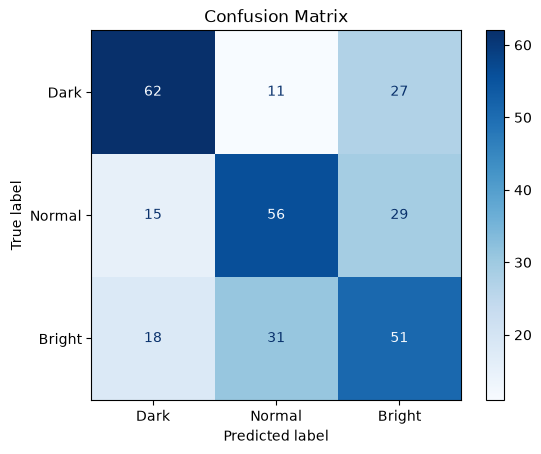

In [16]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Dark", "Normal", "Bright"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

### Multiclass ROC Curve

In [17]:
objective="multi:softprob"

In [18]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Predict class probabilities
y_prob = xgb_model.predict_proba(X_test)

# Binarize labels
classes = [0, 1, 2]
y_test_bin = label_binarize(y_test, classes=classes)

# Compute ROC curve and AUC
fpr = {}
tpr = {}
roc_auc = {}

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

### Plot ROC Curves

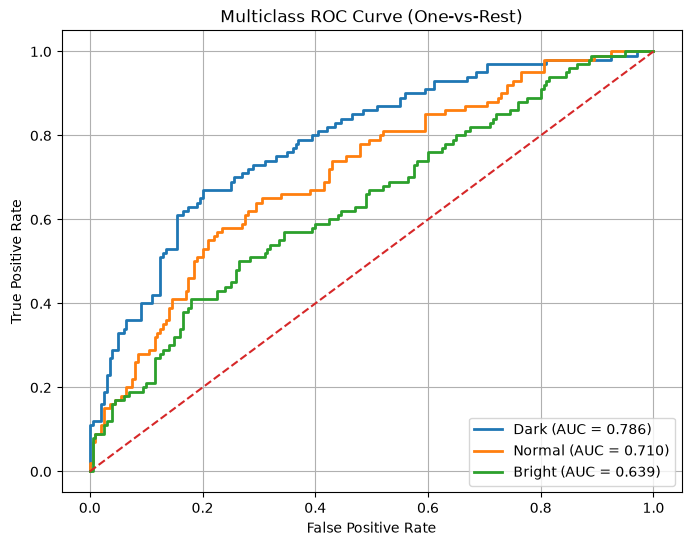

In [19]:
plt.figure(figsize=(8, 6))

class_names = ["Dark", "Normal", "Bright"]

for i in range(len(classes)):
    plt.plot(
        fpr[i],
        tpr[i],
        linewidth=2,
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve (One-vs-Rest)")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

In [20]:
print("ROC-AUC Scores")

for i in range(len(classes)):
    print(f"{class_names[i]} : {roc_auc[i]:.4f}")

ROC-AUC Scores
Dark : 0.7859
Normal : 0.7100
Bright : 0.6389


### Extract Feature Importance

In [21]:
# Get feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Display Top 20 Features
feature_importance.head(20)

,Feature,Importance
0,dark_ratio,0.015027
1,l_mean,0.010146
2,v_mean,0.005572
3,resnet_153,0.005564
4,yolo_255,0.004429
5,resnet_415,0.004355
6,resnet_210,0.004088
7,resnet_147,0.004058
8,resnet_273,0.003919
9,resnet_247,0.003783


### Plot Top 20 Important Features

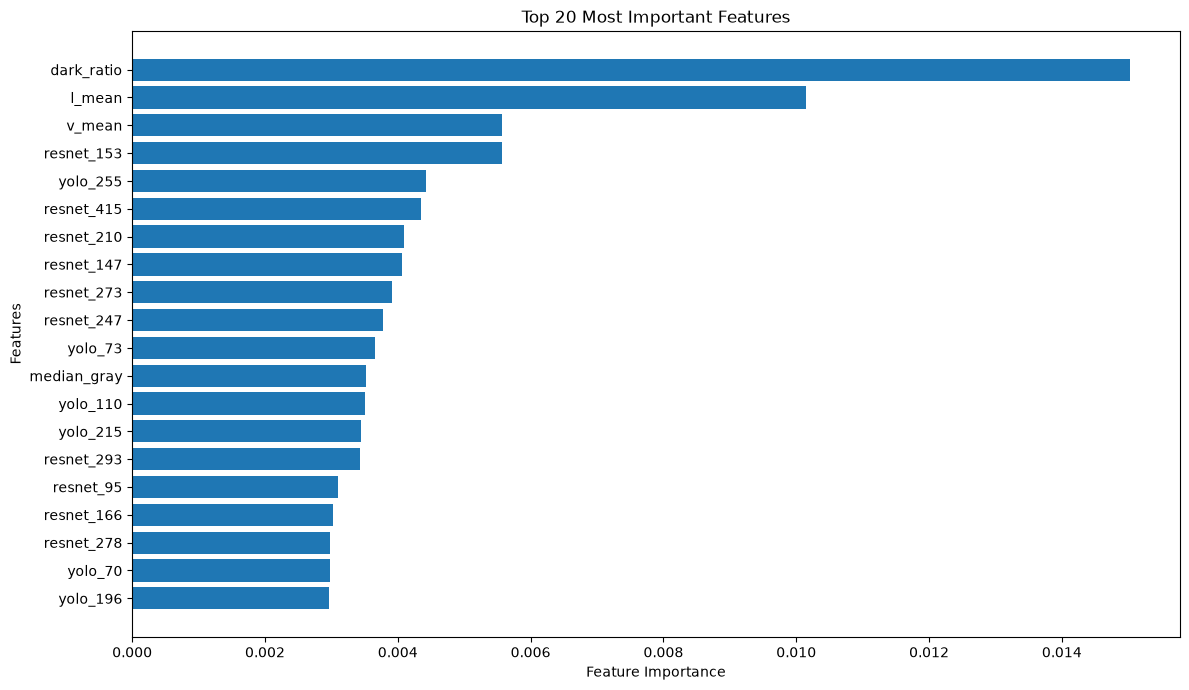

In [22]:
plt.figure(figsize=(12, 7))

plt.barh(
    feature_importance["Feature"][:20][::-1],
    feature_importance["Importance"][:20][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 20 Most Important Features")

plt.tight_layout()
plt.show()

### Multimodal Feature Analysis

In [23]:
top100 = feature_importance.head(100)

resnet_count = top100["Feature"].str.startswith("resnet").sum()
yolo_count = top100["Feature"].str.startswith("yolo").sum()

handcrafted_count = (
    100
    - resnet_count
    - yolo_count
)

print("Top 100 Important Features")

print(f"ResNet Features      : {resnet_count}")
print(f"YOLO Features        : {yolo_count}")
print(f"Handcrafted Features : {handcrafted_count}")

Top 100 Important Features
ResNet Features      : 64
YOLO Features        : 31
Handcrafted Features : 5


### Save the Trained Model

In [25]:
import joblib

joblib.dump(xgb_model, "best_xgboost_model.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [26]:
feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("✅ Feature importance saved!")

✅ Feature importance saved!


In [27]:
import json

metrics = {
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1)
}

with open("evaluation_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("✅ Evaluation metrics saved!")

✅ Evaluation metrics saved!


In [28]:
roc_scores = {
    "Dark": float(roc_auc[0]),
    "Normal": float(roc_auc[1]),
    "Bright": float(roc_auc[2])
}

with open("roc_auc_scores.json", "w") as f:
    json.dump(roc_scores, f, indent=4)

print("✅ ROC-AUC scores saved!")

✅ ROC-AUC scores saved!


In [29]:
modality_contribution = {
    "ResNet": float(resnet_importance),
    "YOLO": float(yolo_importance),
    "Handcrafted": float(handcrafted_importance)
}

with open("modality_contribution.json", "w") as f:
    json.dump(modality_contribution, f, indent=4)

print("✅ Modality contribution saved!")

✅ Modality contribution saved!


In [30]:
print("=" * 60)
print("        XGBOOST TRAINING COMPLETED")
print("=" * 60)

print(f"Accuracy        : {accuracy:.4f}")
print(f"Precision       : {precision:.4f}")
print(f"Recall          : {recall:.4f}")
print(f"F1 Score        : {f1:.4f}")

print("\nROC-AUC")
for i, cls in enumerate(["Dark", "Normal", "Bright"]):
    print(f"{cls:<10}: {roc_auc[i]:.4f}")

print("\nFeature Contribution")
print(f"ResNet      : {resnet_importance:.4f}")
print(f"YOLO        : {yolo_importance:.4f}")
print(f"Handcrafted : {handcrafted_importance:.4f}")

print("\nSaved Files")
print("✓ best_xgboost_model.pkl")
print("✓ feature_importance.csv")
print("✓ evaluation_metrics.json")
print("✓ roc_auc_scores.json")
print("✓ modality_contribution.json")

print("=" * 60)

        XGBOOST TRAINING COMPLETED
Accuracy        : 0.5633
Precision       : 0.5669
Recall          : 0.5633
F1 Score        : 0.5648

ROC-AUC
Dark      : 0.7859
Normal    : 0.7100
Bright    : 0.6389

Feature Contribution
ResNet      : 0.6527
YOLO        : 0.2935
Handcrafted : 0.0538

Saved Files
✓ best_xgboost_model.pkl
✓ feature_importance.csv
✓ evaluation_metrics.json
✓ roc_auc_scores.json
✓ modality_contribution.json


In [32]:
resnet_importance = feature_importance[
    feature_importance["Feature"].str.startswith("resnet")
]["Importance"].sum()

yolo_importance = feature_importance[
    feature_importance["Feature"].str.startswith("yolo")
]["Importance"].sum()

handcrafted_importance = feature_importance[
    ~(feature_importance["Feature"].str.startswith("resnet") |
      feature_importance["Feature"].str.startswith("yolo"))
]["Importance"].sum()

In [33]:
# Predictions on training data
y_train_pred = xgb_model.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_pred)

print(f"Training Accuracy : {train_accuracy:.4f}")
print(f"Testing Accuracy  : {accuracy:.4f}")

Training Accuracy : 1.0000
Testing Accuracy  : 0.5633
